# Introduction to Statistical Learning
## Chapter 4 exercises - Classification problems

In [1]:
# Import standard libraries
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots

from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                         summarize,
                         poly)
import statsmodels.api as sm

In [2]:
# We need the following imports for these exercises
from ISLP import confusion_table
from sklearn.discriminant_analysis import \
     (LinearDiscriminantAnalysis as LDA,
      QuadraticDiscriminantAnalysis as QDA)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

#### Exercise 13

In [3]:
# Load the 'Weekly' data, which contains contains 1,089
# weekly returns for 21 years, from the beginning of 1990 to the end of 2010.
Weekly = load_data("Weekly")
Weekly

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up
...,...,...,...,...,...,...,...,...,...
1084,2010,-0.861,0.043,-2.173,3.599,0.015,3.205160,2.969,Up
1085,2010,2.969,-0.861,0.043,-2.173,3.599,4.242568,1.281,Up
1086,2010,1.281,2.969,-0.861,0.043,-2.173,4.835082,0.283,Up
1087,2010,0.283,1.281,2.969,-0.861,0.043,4.454044,1.034,Up


 (a) Produce some numerical and graphical summaries of the Weekly data

In [4]:
# We show the correlation table
Weekly.corr(numeric_only=True)

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
Year,1.000000,-0.032289,-0.033390,-0.030006,-0.031128,-0.030519,0.841942,-0.032460
Lag1,-0.032289,1.000000,-0.074853,0.058636,-0.071274,-0.008183,-0.064951,-0.075032
Lag2,-0.033390,-0.074853,1.000000,-0.075721,0.058382,-0.072499,-0.085513,0.059167
Lag3,-0.030006,0.058636,-0.075721,1.000000,-0.075396,0.060657,-0.069288,-0.071244
Lag4,-0.031128,-0.071274,0.058382,-0.075396,1.000000,-0.075675,-0.061075,-0.007826
Lag5,-0.030519,-0.008183,-0.072499,0.060657,-0.075675,1.000000,-0.058517,0.011013
Volume,0.841942,-0.064951,-0.085513,-0.069288,-0.061075,-0.058517,1.000000,-0.033078
Today,-0.032460,-0.075032,0.059167,-0.071244,-0.007826,0.011013,-0.033078,1.000000


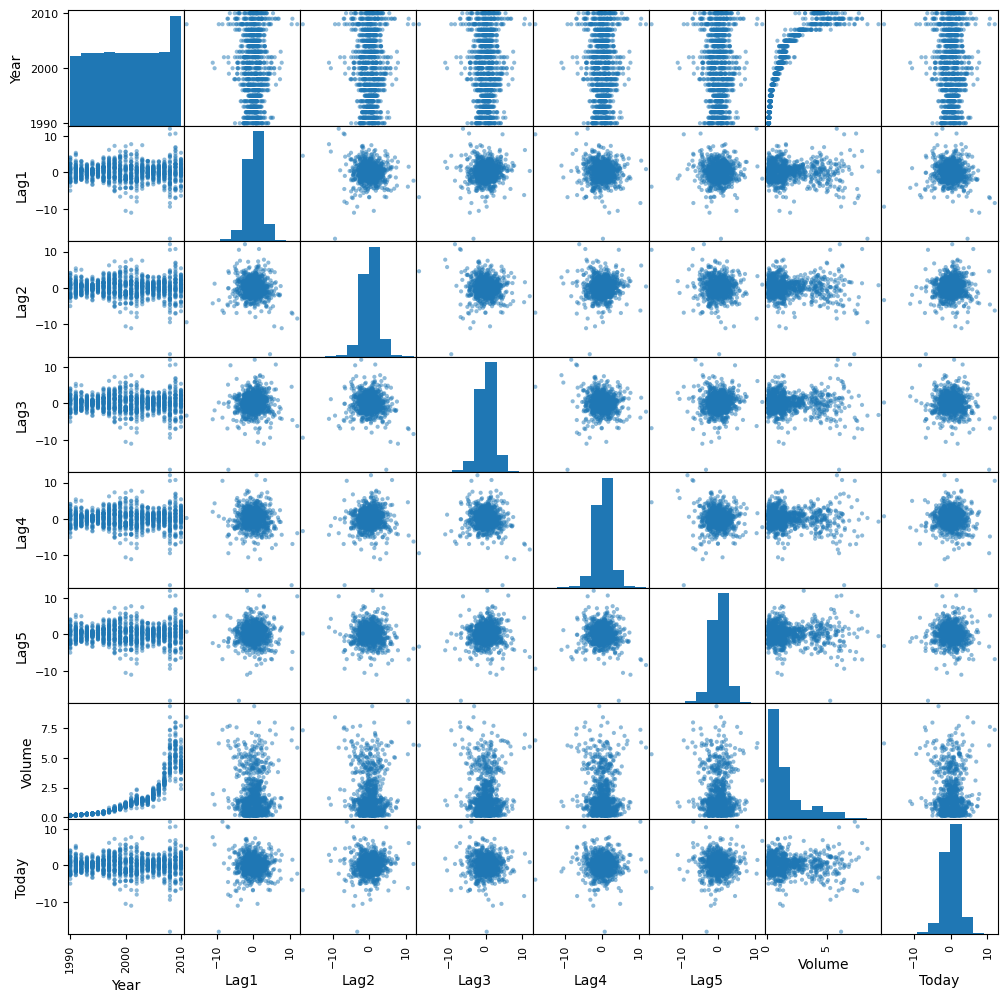

In [5]:
# Produce a scatterplot matrix with all the variables
ax = pd.plotting.scatter_matrix(Weekly, figsize=(12, 12))

No significant correlations are observed among the variables, with the exception of a pronounced relationship between `Volume` and `Year`.


In [6]:
# Fit a logistic regression model of `Direction` on the lag variables and `Volume`
predictors = Weekly.columns.drop(['Today','Direction','Year'])
design = MS(predictors)
X = design.fit_transform(Weekly)
y = (Weekly['Direction'] == 'Up')

glm = sm.GLM(y, X, family=sm.families.Binomial())
results = glm.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:              Direction   No. Observations:                 1089
Model:                            GLM   Df Residuals:                     1082
Model Family:                Binomial   Df Model:                            6
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -743.18
Date:                Wed, 30 Apr 2025   Deviance:                       1486.4
Time:                        00:27:30   Pearson chi2:                 1.09e+03
No. Iterations:                     4   Pseudo R-squ. (CS):           0.009000
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.2669      0.086      3.106      0.002       0.098       0.435
Lag1          -0.0413      0.026     -1.563      0.118      -0.093       0.010
Lag2           0.0584      0.027      2.175      0.030       0.006       0.111
Lag3          -0.0161      0.027     -0.602      0.547      -0.068       0.036
Lag4          -0.0278      0.026     -1.050      0.294      -0.080       0.024
Lag5          -0.0145      0.026     -0.549      0.583      -0.066       0.037
Volume        -0.0227      0.037     -0.616      0.538      -0.095       0.050
==============================================================================
"""

Only the predictor `lag2` seems to be statistically significant.

In [7]:
# (c) Compute the confusion matrix
probability = results.predict()
labels = np.array(['Down']*1089)
labels[probability > 0.5] = "Up"

confusion_table(labels, Weekly['Direction'])

Truth,Down,Up
Predicted,,
Down,54,48
Up,430,557


In [8]:
# Calculate the fraction correct with values given above
fraction_correct = (557+54)/1089
print('fraction correct is',fraction_correct)

fraction correct is 0.5610651974288338


Just over half the predictions (56%) are correct, which is slightly better than random chance. The model predicts 'Up' much more than 'Down', so the majority of errors are false positive predictions.

In [9]:
# (d) Fit the logistic regression model using data from 1990 to 2008 and using Lag2 as the only predictor

pre2009 = Weekly['Year'] < 2009

Weeklypre2009 = Weekly.loc[pre2009]
Weeklypost2009 = Weekly.loc[~pre2009]

train_size = len(Weeklypre2009)
test_size = len(Weeklypost2009)

new_design = MS(['Lag2'])
X_train = new_design.fit_transform(Weeklypre2009)
X_test = new_design.fit_transform(Weeklypost2009)
y_train = (Weeklypre2009['Direction'] == 'Up')
y_test = (Weeklypost2009['Direction'] == 'Up')

glm2 = sm.GLM(y_train, X_train, family=sm.families.Binomial())
results2 = glm2.fit()
results2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:              Direction   No. Observations:                  985
Model:                            GLM   Df Residuals:                      983
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -675.27
Date:                Wed, 30 Apr 2025   Deviance:                       1350.5
Time:                        00:27:30   Pearson chi2:                     985.
No. Iterations:                     4   Pseudo R-squ. (CS):           0.004221
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.2033      0.064      3.162      0.002       0.077       0.329
Lag2           0.0581      0.029      2.024      0.043       0.002       0.114
==============================================================================
"""

In [10]:
# Predict using test data and create the confusion matrix

probability2 = results2.predict(exog = X_test)
labels2 = np.array(['Down']*test_size)
labels2[probability2 > 0.5] = "Up"

confusion_table(labels2, Weeklypost2009['Direction'])

Truth,Down,Up
Predicted,,
Down,9,5
Up,34,56


In [11]:
# Calculate the fraction correct with values given above
fraction_correct = (9+56)/test_size
print('fraction correct is',fraction_correct)

fraction correct is 0.625


In [12]:
# (e) Repeat (d) using LDA.

lda = LDA(store_covariance=True)
lda.fit(X_train, y_train)

lda_predictions = lda.predict(X_test)
confusion_table(lda_predictions, y_test)

Truth,False,True
Predicted,,
False,9,5
True,34,56


The confusion matrix is identical to that of the logistic regression model, yielding an accuracy of roughly 62.5%.

In [13]:
# (f) Repeat (d) using QDA.

qda = QDA(store_covariance=True, reg_param=0.8)
qda.fit(X_train, y_train)

qda_predictions = qda.predict(X_test)
confusion_table(qda_predictions, y_test)

Truth,False,True
Predicted,,
False,13,14
True,30,47


In [14]:
# Calculate the fraction correct with values given above
fraction_correct = (13+47)/(13+47+30+14)
print('fraction correct is',fraction_correct)

fraction correct is 0.5769230769230769


In [15]:
# (g) Repeat (d) using KNN with K = 1.

KNN1 = KNeighborsClassifier(n_neighbors=1)
KNN1.fit(X_train, y_train)

KNN1_predictions = KNN1.predict(X_test)
confusion_table(KNN1_predictions, y_test)

Truth,False,True
Predicted,,
False,22,31
True,21,30


In [16]:
# Calculate the fraction correct with values given above
fraction_correct = (22+30)/(22+31+21+30)
print('fraction correct is',fraction_correct)

fraction correct is 0.5


Since we've seen that LDA outperforms the QDA, it is reasonable to expect KNN to perform badly. The decision boundary is morse likely to be linear. Moreover, with a ratio of approximately 17 observations per predictor, this dataset does not provide enough data to support the use of a non-parametric technique such as KNN.

#### Exercise 14

In this problem, you will develop a model to predict whether a given car gets high or low gas mileage based on the `Auto` data set.

In [17]:
# Load the Auto dataset
Auto = load_data("Auto")

mpg_median = Auto["mpg"].median()
Auto['mpg01'] = np.where(Auto["mpg"] > mpg_median, 1, 0)
Auto

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,mpg01
name,,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1,0
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1,0
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1,0
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1,0
ford torino,17.0,8,302.0,140,3449,10.5,70,1,0
...,...,...,...,...,...,...,...,...,...
ford mustang gl,27.0,4,140.0,86,2790,15.6,82,1,1
vw pickup,44.0,4,97.0,52,2130,24.6,82,2,1
dodge rampage,32.0,4,135.0,84,2295,11.6,82,1,1


In [18]:
Auto.corr(numeric_only=True)

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,mpg01
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.565209,0.836939
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.568932,-0.759194
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.614535,-0.753477
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171,-0.667053
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.585005,-0.757757
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.212746,0.346822
year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,0.181528,0.429904
origin,0.565209,-0.568932,-0.614535,-0.455171,-0.585005,0.212746,0.181528,1.000000,0.513698
mpg01,0.836939,-0.759194,-0.753477,-0.667053,-0.757757,0.346822,0.429904,0.513698,1.000000


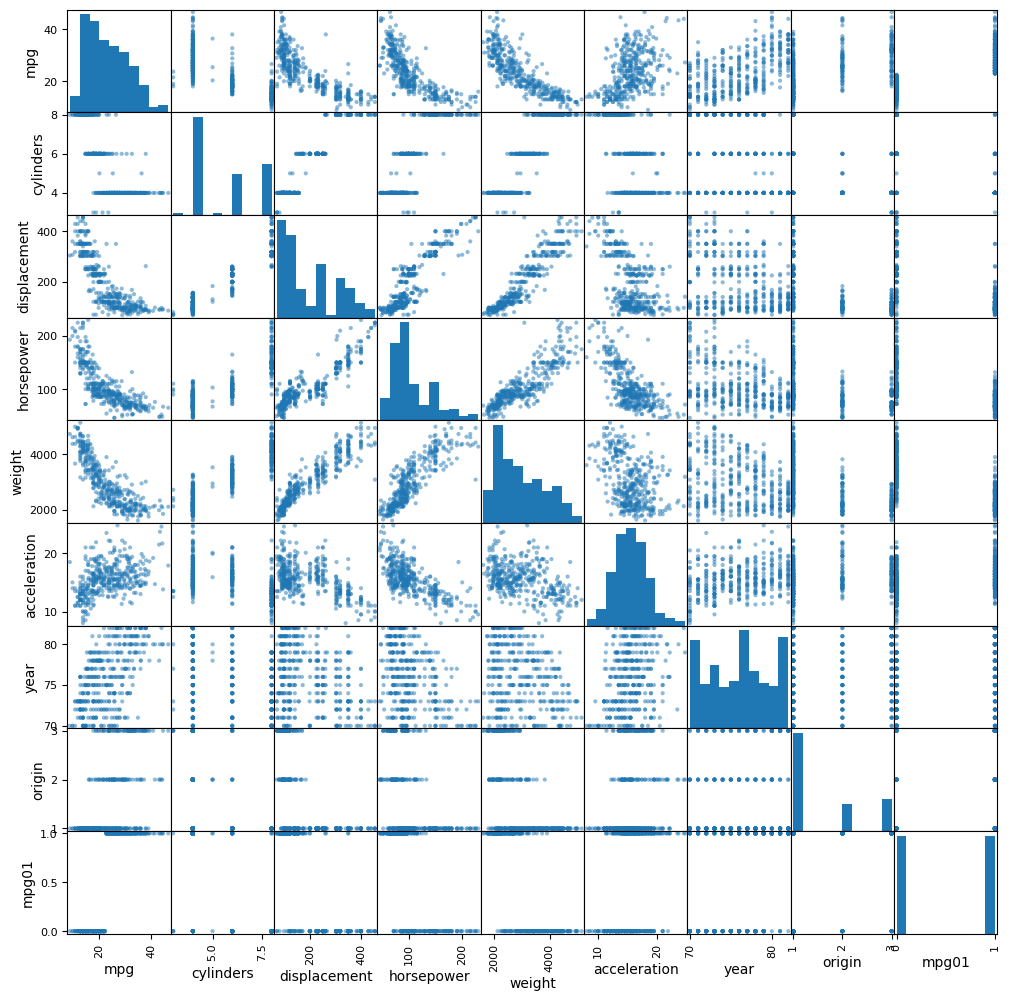

In [19]:
ax = pd.plotting.scatter_matrix(Auto, figsize=(12, 12))

In [20]:
# Both the scatterplots and the correlation matrix indicate that mpg01 is strongly associated with displacement, weight, horsepower and cylinders.

In [21]:
predictors = Auto.columns.drop(['mpg','mpg01','acceleration','year','origin'])
design = MS(predictors)
X = design.fit_transform(Auto)
y = (Auto['mpg01'] == 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1  # random_state ensures reproducibility
)

In [22]:
# (d) Perform LDA on the training data
lda = LDA(store_covariance=True)
lda.fit(X_train, y_train)

lda_predictions = lda.predict(X_test)
confusion_table(lda_predictions, y_test)

Truth,False,True
Predicted,,
False,58,3
True,7,50


#### Exercise 15

In [23]:
def Power():
    print(2**3)

def Power2(x, a):
    print(x**a)

Power2(3, 8)

6561


In [24]:
Power2(10,3)
Power2(8,17)
Power2(131,3)

1000
2251799813685248
2248091


In [25]:
def Power3(x, a):
    return x**a

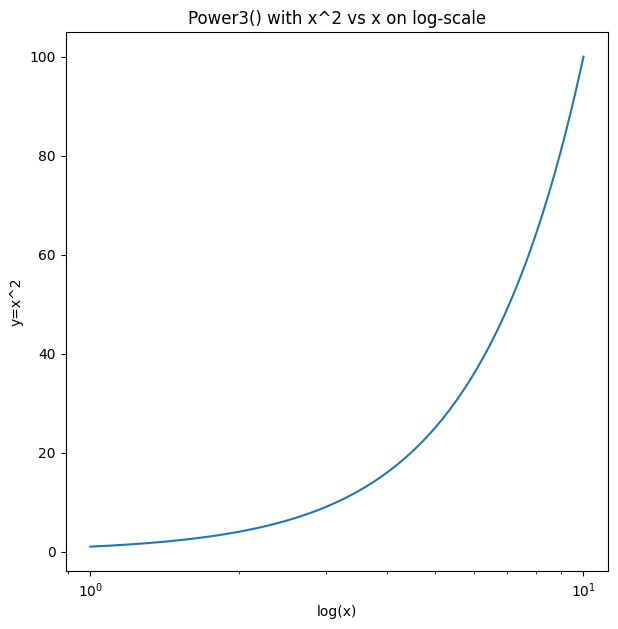

In [26]:
# Using the Power3() function, create a plot of f(x) = x^2
x = np.linspace(1,10,100)
y = Power3(x,2)


fig, ax = subplots(figsize=(7,7))
ax.set_xscale('log')
ax.set_title('Power3() with x^2 vs x on log-scale')
ax.set_xlabel('log(x)')
ax.set_ylabel('y=x^2')
ax.plot(x,y);